In [ ]:
import numpy as np
import pandas as pd
import os
import time
from tqdm import tqdm, trange
import sys
import matplotlib.pyplot as plt
import pickle

# variaveis
L = 100 # lado do lattice
n_lagartos = L**2 # lagartos que cabem no lattice
estrategias = ['O', 'Y', 'B'] # estratégias possíveis
index_map = {'O': 0, 'Y': 1, 'B': 2}
n_geracoes = 100
n_pop = 3 # número de populações independentes
prob_mutacao = None # probabilidade de mutação a cada geração
minimo_O = float(input("Minimo O: "))
maximo_O = float(input("Maximo O: "))
inclinacao_O = float(input("Inclinacao O: "))
minimo_B = float(input("Minimo B: "))
maximo_B = float(input("Maximo B: "))
inclinacao_B = float(input("Inclinacao B: "))
tipo = f"O_{minimo_O}-{maximo_O}_incO{inclinacao_O}_B{minimo_B}-{maximo_B}_incB{inclinacao_B}"

output_dir = "C:\\Unicamp\\mestrado\\simulacoes\\RPS-python\\RPS-POO\\outputs\\custo_Y\\" + tipo + "/"
os.makedirs(output_dir, exist_ok=True)

NameError: name 'output_dir' is not defined

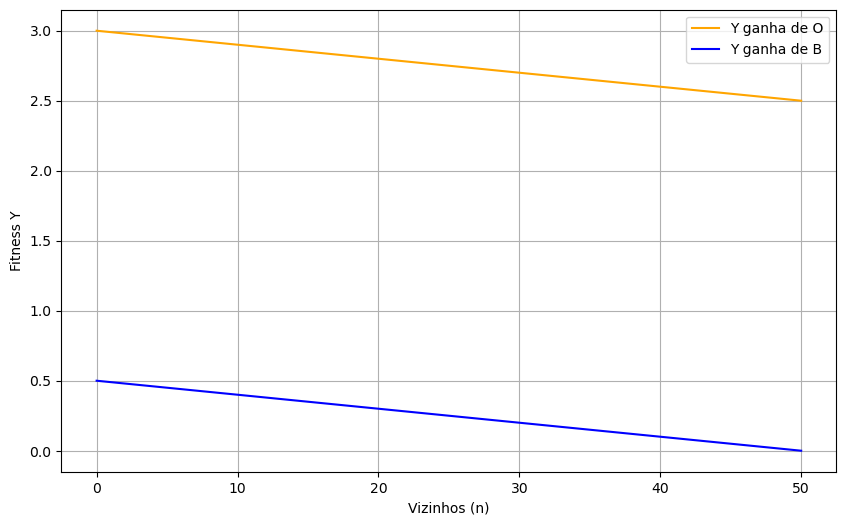

In [ ]:
def calcular_custo(n_vizinhos, inclinacao, minimo, limite):
    custo = (n_vizinhos * inclinacao) + minimo
    return np.minimum(custo, limite)

plt.figure(figsize=(10, 6))
vizinho = np.linspace(0, 50, 100)

c_values = calcular_custo(vizinho, inclinacao_O, minimo_O, maximo_O)
#c_values = calcular_custo(vizinho, inclinacao = 0.01, minimo = -1, limite = 1.5)
fitness_Y_O = 2 - c_values
b_values = calcular_custo(vizinho, inclinacao_B, minimo_B, maximo_B)
#b_values = calcular_custo(vizinho, inclinacao = 0.01, minimo = 1.5, limite = 3)
fitness_Y_B = 2 - b_values
cruzam = np.any(np.diff(np.sign(fitness_Y_O - fitness_Y_B)) != 0)

if cruzam == True:
    pass

else:

    plt.plot(vizinho, fitness_Y_O, label='Y ganha de O', color='orange')
    plt.plot(vizinho, fitness_Y_B, label='Y ganha de B', color='blue')

    plt.xlabel('Vizinhos (n)')
    plt.ylabel('Fitness Y')
    plt.legend()
    plt.grid()
    plt.savefig(output_dir + "grafico_cO_cB.png")
    plt.show()

In [31]:
class Lagarto:
  def __init__(self, i, j, estrategia, fitness, coord_vizinhos, estrategia_vizinhos, coord_vizinhanca_extendida, estrategia_vizinhanca_extendida, t, n_vizinhos, n_vizinhos_realizado):
    self.i = i # linha
    self.j = j # coluna
    self.estrategia = estrategia
    self.fitness = 0 # inicia com 0 de fitness
    self.coord_vizinhos = [] # lista vazia para adicionar as coordenadas dos vizinhos
    self.estrategia_vizinhos = [] # lista vazia para adicionar as estratégias dos vizinhos
    self.coord_vizinhanca_extendida = []
    self.estrategia_vizinhanca_extendida = []
    self.t = 0 # determina a geracao do lagarto
    self.n_vizinhos = 0 # número de vizinhos
    self.n_vizinhos_realizado = 0 # número de vizinhos realizados


  def calcular_coord_vizinhos(self, L): # obtém as coordenadas dos vizinhos

    lista_vizinhos = []
    vizinhos_possiveis = []
    n_v = self.n_vizinhos

    for dx in range(-3, 4): 
        for dy in range(-3, 4):
            if dx == 0 and dy == 0: # ignora ele mesmo
                continue
            ni = (self.i + dx) % L # fronteiras periódicas
            nj = (self.j + dy) % L # fronteiras periódicas
            vizinhos_possiveis.append(((ni, nj), max(abs(dx), abs(dy)))) # armazena a coordenada dos vizinhos possíveis e a sua distância até o lagarto atual
        # Ordena os vizinhos por distância (mais próximos primeiro)
        vizinhos_possiveis.sort(key=lambda x: x[1])
        lista_vizinhos = [coord for coord, _ in vizinhos_possiveis[:n_v]]

    self.coord_vizinhos = lista_vizinhos # armazena as coordenadas dos vizinhos na variável do lagarto
    
  def obter_estrategia_vizinhos(self, matriz_posicao):
      self.estrategia_vizinhos = [matriz_posicao[ni, nj] for ni, nj in self.coord_vizinhos] # dadas as coordenadas, obtém a estratégia do lagarto que ocupa aquela posição

  def mutacao(self, prob_mutacao): # função de mutação
    if np.random.rand() < prob_mutacao: # sorteia um valor entre 0 e 1, se for menor que a probabilidade de mutação, o lagarto muda de estratégia
        estrategias_possiveis = [e for e in estrategias if e != self.estrategia] # obtém as estratégias possíveis, exceto a atual
        self.estrategia = np.random.choice(estrategias_possiveis) # escolhe uma nova estratégia aleatoriamente para mutar

  def calcular_n_vizinhos(self): # calcula o número de vizinhos
      self.n_vizinhos_realizado = len(self.coord_vizinhos) + len(self.coord_vizinhanca_extendida)

  def calcular_custo(self, inclinacao, minimo, limite):
      if self.estrategia == 'Y':
          custo = (self.n_vizinhos * inclinacao) + minimo
      return np.minimum(custo, limite)
  
  def adicionar_vizinhos_inicial(self):
      if self.estrategia == 'Y':
          n_vizinho = np.random.randint(1, 49)
          self.n_vizinhos = n_vizinho
      elif self.estrategia == 'O':
          n_vizinho = 24
          #n_vizinho = np.random.randint(1, 49)
          self.n_vizinhos = n_vizinho
      elif self.estrategia == 'B':
          n_vizinho = 8
          #n_vizinho = np.random.randint(1, 49)
          self.n_vizinhos = n_vizinho

def calcular_media_vizinhos(lagartos, estrategias):
    medias = []
    for e in estrategias:
        #viz = [lag.n_vizinhos_realizado for lag in lagartos if lag.estrategia == e]
        viz = [lag.n_vizinhos for lag in lagartos if lag.estrategia == e]
        medias.append(np.mean(viz) if len(viz) > 0 else 0)
    return medias # retorna a média de vizinhos para cada estratégia

def ajustar_vizinhos_reciprocos(lagartos): # garante que se A é vizinho de B, B também é vizinho de A, pois as interações são recíprocas
    mapa = {(l.i, l.j): l for l in lagartos} # dicionário pra acessar lagartos pela posição

    for l in lagartos:
        for (ni, nj) in l.coord_vizinhos: # vai em todos os vizinhos do lagarto atual (l)
            vizinho = mapa[(ni, nj)]
            # se o lagarto atual (l) não estiver na lista de vizinhos do vizinho, adiciona em vizinhanca_extendida
            if (l.i, l.j) not in vizinho.coord_vizinhos:
                vizinho.estrategia_vizinhanca_extendida.append(str(l.estrategia))
                vizinho.coord_vizinhanca_extendida.append((l.i, l.j))

In [32]:
def criar_lagartos(n_lagartos, L, estrategias): # define as posições e estratégias dos lagartos no t = 0
  lista_lagartos = []

  # posições iniciais aleatórias
  all_positions = [(i, j) for i in range(L) for j in range(L)] # forma todas as posições possíveis em um lattice
  unique_positions_indices = np.random.choice(len(all_positions), n_lagartos, replace=False) # determina o índice de onde vai ficar cada posição
  unique_positions = [all_positions[i] for i in unique_positions_indices] # basicamente, ele embaralhou as posições

  for g in range(n_lagartos):
    i, j = unique_positions[g] # posição na matriz
    estrategia = np.random.choice(estrategias) # sorteia a estrategia
    lista_lagartos.append(Lagarto(i, j, estrategia, 0, [], [], [], [], 0, 0, 0)) # cria o lagarto
  return lista_lagartos

def calcular_fitness(lagarto, index_map, matriz_posicao, minimo_O, maximo_O, inclinacao_O, minimo_B, maximo_B, inclinacao_B): # função para calcular o fitness do lagarto
    fitness_total = 0 # inicia no 0

    b = 2 # ganho em fitness ao vencer
    c = 1.5
    #c_O = 0.9
    #c_B = 2

    if lagarto.estrategia == 'Y':
        c_O = lagarto.calcular_custo(inclinacao = inclinacao_O, minimo = minimo_O, limite = maximo_O) # custo para Y por ter vizinhos O
        c_B = lagarto.calcular_custo(inclinacao = inclinacao_B, minimo = minimo_B, limite = maximo_B) # custo para Y por ter vizinhos B
    else:
        c_O = 0
        c_B = 1.5
    
    matriz_payoff = np.array([[1, b-c, b],
                              [b-c_O, 1, b-c_B],
                              [b-c, b, 1]])
    
    todos_vizinhos = set(lagarto.coord_vizinhos + lagarto.coord_vizinhanca_extendida) # junta todos os vizinhos (normais e estendidos) em um set para evitar que um vizinho seja contado duas vezes
    for ni, nj in todos_vizinhos:
        vizinho_estrat = matriz_posicao[ni, nj] # pega a estratégia do vizinho dadas as suas coordenadas
        if vizinho_estrat is not None:
            fitness_total += matriz_payoff[index_map[lagarto.estrategia], index_map[vizinho_estrat]] # calcula o payoff do lagarto contra o vizinho de acordo com a matriz de payoff e soma ao fitness total
    lagarto.fitness = fitness_total
    return fitness_total

calcular_freq = lambda mat: np.array([np.sum(mat == s) / (L ** 2) for s in ['O', 'Y', 'B']]) # calcula a frequência de cada estratégia no lattice na ordem O, Y, B

In [34]:
def atualizar_lagartos(lagartos): # função que atualiza as estratégias dos lagartos com base no fitness dos vizinhos
    novas_estrategias = {} # Dicionário para armazenar as novas estratégias
    novas_vizinhancas = {} # Dicionário para armazenar as novas vizinhanças

    mapa = {(l.i, l.j): l for l in lagartos} # dicionário para acessar lagartos pela posição

    for lagarto in lagartos:
        melhor_estrategia = lagarto.estrategia # inicia com a própria estratégia
        maior_fitness = lagarto.fitness # verifica o fitness do próprio lagarto
        melhor_vizinhanca = lagarto.n_vizinhos
            
        # verifica o fitness dos vizinhos normais
        for (ni, nj) in lagarto.coord_vizinhos:
            vizinho = mapa[(ni, nj)] # usa o dicionário para achar o vizinho
            if vizinho.fitness > maior_fitness: # se o fitness do vizinho for maior que o maior fitness atual
                maior_fitness = vizinho.fitness # atualiza o maior fitness
                melhor_estrategia = vizinho.estrategia # atualiza a melhor estratégia
                melhor_vizinhanca = vizinho.n_vizinhos
            if vizinho.fitness == maior_fitness:
                a = np.random.rand()
                if a < 0.5:
                    maior_fitness = vizinho.fitness # atualiza o maior fitness
                    melhor_estrategia = vizinho.estrategia # atualiza a melhor estratégia
                    melhor_vizinhanca = vizinho.n_vizinhos
                else:
                    pass
                # se houver empate de fitness ou for menor, mantém a estratégia atual (não muda)

        # verifica o fitness dos vizinhos extendidos
        for (ni, nj) in lagarto.coord_vizinhanca_extendida:
            vizinho = mapa[(ni, nj)] 
            if vizinho.fitness > maior_fitness:
                maior_fitness = vizinho.fitness
                melhor_estrategia = vizinho.estrategia
                melhor_vizinhanca = vizinho.n_vizinhos
            if vizinho.fitness == maior_fitness:
                a = np.random.rand()
                if a < 0.5:
                    maior_fitness = vizinho.fitness # atualiza o maior fitness
                    melhor_estrategia = vizinho.estrategia # atualiza a melhor estratégia
                    melhor_vizinhanca = vizinho.n_vizinhos
                else:
                    pass

        novas_estrategias[(lagarto.i, lagarto.j)] = melhor_estrategia # armazena a nova estratégia no dicionário
        novas_vizinhancas[(lagarto.i, lagarto.j)] = melhor_vizinhanca # armazena a nova vizinhança no dicionário

    # atualiza as estratégias de todos os lagartos simultaneamente
     # atualiza as estratégias de todos os lagartos simultaneamente
    for lagarto in lagartos:
        lagarto.estrategia = novas_estrategias[(lagarto.i, lagarto.j)]  # atualiza estratégia
        # Garantir tamanhos fixos para O e B; somente Y herda vizinhança adaptativa
        if lagarto.estrategia == 'O':
            lagarto.n_vizinhos = 24
        elif lagarto.estrategia == 'B':
            lagarto.n_vizinhos = 8
        else:  # 'Y'
            lagarto.n_vizinhos = novas_vizinhancas[(lagarto.i, lagarto.j)]
        #lagarto.n_vizinhos = novas_vizinhancas[(lagarto.i, lagarto.j)]
    
    return lagartos

Etapas da simulação:
1. cria os lagartos com posição e estratégia
2. adiciona o número de vizinhos de acordo com a estratégia
3. determina quem são os vizinhos de cada lagarto (coordenada e estratégia)
4. ajusta vizinhos recíprocos (pega coordenada e estratégia)
5. recalcula o número de vizinhos efetivos de acordo com a reciprocidade
6. armazena a média do número de vizinhos por estratégia
7. calcula o fitness de cada lagarto com base nos seus vizinhos e no jogo
8. atualiza os lagartos, substituindo a estratégia e o número de vizinhos daquele com maior fitness
9. permite mutação de prob_mutação não for None
10. cria uma nova matriz de posição com os lagartos atualizados
11. calcula as frequências das estratégias

Explicando cada variável dentro da função:

1. matriz_frequencias:
        Matriz 3D que armazena a frequência de cada estratégia em cada geração e população.
        Eixo 0: gerações (de 0 até n_geracoes)
        Eixo 1: populações independentes
        Eixo 2: tem tamanho 3 e vai armazenar as frequências das estratégias (O, Y, B) no formato [0.3, 0.3, 0.3]

2. matriz_n_vizinhos_media:
        Matriz 3D que armazena a média do número de vizinhos realizados para cada estratégia, geração e população.
        Mesma estrutura de índices que matriz_frequencias, mas armazena o número de vizinhos no formato [x, y, z]

3. n_vizinhos_individual:
        Lista de listas de listas:
                Para cada população:
                        Para cada geração:
                                Para cada lagarto: número de vizinhos realizados daquele lagarto.
        Exemplo: n_vizinhos_individual[pop][t][i] é o número de vizinhos do lagarto i na geração t da população pop.

4. historico_estrategias:
        Mesmo formato do n_vizinhos_individual, mas para cada lagarto, temos a estratégia daquele lagarto.
        Exemplo: historico_estrategias[pop][t][i] é a estratégia do lagarto i na geração t da população pop.

In [35]:
# iniciando a simulação
def simulacao(n_geracoes, L, n_lagartos, estrategias, index_map, n_pop, minimo_O, maximo_O, inclinacao_O, minimo_B, maximo_B, inclinacao_B, prob_mutacao = None, seed = None):
    matriz_frequencias = np.full((n_geracoes + 1, n_pop, len(estrategias)), np.nan, dtype=float) # cria uma matriz para armazenar as frequências em cada instante dos loops
    matriz_n_vizinhos_media = np.full((n_geracoes + 1, n_pop, len(estrategias)), np.nan, dtype=float) # cria uma matriz para armazenar vizinhos
    n_vizinhos_individual = []  # lista para armazenar todos os números de vizinhos
    historico_estrategias = [] # lista para armazenar o histórico de estratégias de cada população

    for pop in range(n_pop): # loop para cada população independente
        if seed is not None:
          np.random.seed(seed + pop) # coloca uma semente diferente pra cada pop, garantindo independência e reproducibilidade

        frequencias = [] # vai armazenar as frequências ao longo das gerações para essa população
        matriz_posicao = np.full((L, L), None) # cria uma matriz vazia com None
        n_vizinhos_pop = []  # [pop][t][i]
        historico_estrategias_pop = []
        
        lista_lagartos = criar_lagartos(n_lagartos, L, estrategias) # cria os lagartos
        for lagarto in lista_lagartos:
            lagarto.adicionar_vizinhos_inicial() # adiciona o número de vizinhos iniciais de acordo com a estratégia
            matriz_posicao[lagarto.i, lagarto.j] = str(lagarto.estrategia) # cria a matriz de posições de acordo com os lagartos

        frequencias.append(calcular_freq(matriz_posicao)) # calcula a frequência inicial
        n_vizinhos_pop.append([lagarto.n_vizinhos for lagarto in lista_lagartos])  # geração inicial
        historico_estrategias_pop.append([lagarto.estrategia for lagarto in lista_lagartos])  # histórico de estratégias
        matriz_n_vizinhos_media[0, pop, :] = calcular_media_vizinhos(lista_lagartos, estrategias)

        for t in range(1, n_geracoes + 1): # loop para cada geração dentro da população
          # determinando os vizinhos
          for lagarto in lista_lagartos:
            lagarto.calcular_coord_vizinhos(L) # calcula as coordenadas dos vizinhos
            lagarto.obter_estrategia_vizinhos(matriz_posicao) # obtém as estratégias dos vizinhos
            # zera a vizinhança estendida para recalcular a cada lagarto
            lagarto.coord_vizinhanca_extendida = [] 
            lagarto.estrategia_vizinhanca_extendida = [] 

          ajustar_vizinhos_reciprocos(lista_lagartos) # ajusta as vizinhanças recíprocas

          for lagarto in lista_lagartos:
            lagarto.calcular_n_vizinhos() # calcula o número de vizinhos efetivo

          # calculando o fitness
          for lagarto in lista_lagartos:
            calcular_fitness(lagarto, index_map, matriz_posicao, minimo_O, maximo_O, inclinacao_O, minimo_B, maximo_B, inclinacao_B) # calcula o fitness do lagarto de acordo com seus vizinhos e a matriz de fitness

          lista_lagartos = atualizar_lagartos(lista_lagartos) # atualiza as estratégias dos lagartos de acordo com o maior fitness dos vizinhos

          if prob_mutacao is not None:
            for lagarto in lista_lagartos:
              lagarto.mutacao(prob_mutacao) # aplica a mutação

          # atualiza a matriz de posição com as novas estratégias e com as mutações
          matriz_posicao = np.full((L, L), None)
          for lagarto in lista_lagartos:
            matriz_posicao[lagarto.i, lagarto.j] = str(lagarto.estrategia)
          #print(matriz_posicao)

          # ----- RECOMPUTAR VIZINHANÇAS USANDO O NOVO n_vizinhos -----
          for lagarto in lista_lagartos:
              # limpa vizinhança estendida e recalcula vizinhos diretos conforme novo n_vizinhos
              lagarto.coord_vizinhanca_extendida = []
              lagarto.estrategia_vizinhanca_extendida = []
              lagarto.calcular_coord_vizinhos(L)
              lagarto.obter_estrategia_vizinhos(matriz_posicao)
          ajustar_vizinhos_reciprocos(lista_lagartos)
          for lagarto in lista_lagartos:
              lagarto.calcular_n_vizinhos()
          # ---------------------------------------------------------

          n_vizinhos_geracao = [lagarto.n_vizinhos_realizado for lagarto in lista_lagartos]
          n_vizinhos_pop.append(n_vizinhos_geracao)
          matriz_n_vizinhos_media[t, pop, :] = calcular_media_vizinhos(lista_lagartos, estrategias) # calcula a média de vizinhos para cada estratégia e armazena na matriz n_vizinhos
          #print(matriz_n_vizinhos[t, pop, :]) # debug
          historico_estrategias_pop.append([lagarto.estrategia for lagarto in lista_lagartos])  # histórico de estratégias
          frequencias.append(calcular_freq(matriz_posicao)) # calcula a frequência dessa geração e armazena em frequencias

          for lagarto in lista_lagartos:
              lagarto.t += 1 # incrementa a geração do lagarto
          
        frequencias = np.array(frequencias)
        n_vizinhos_individual.append(n_vizinhos_pop)
        historico_estrategias.append(historico_estrategias_pop)
        for t in range(n_geracoes + 1):
          matriz_frequencias[t, pop, :] = frequencias[t]

          # >>>>> SALVAR OS DADOS DESTA POPULAÇÃO <<<<<
        with open(os.path.join(output_dir, f"pop_{pop}_n_vizinhos_individual.pkl"), "wb") as f:
          pickle.dump(n_vizinhos_pop, f)
        with open(os.path.join(output_dir, f"pop_{pop}_historico_estrategias.pkl"), "wb") as f:
          pickle.dump(historico_estrategias_pop, f)
        np.save(os.path.join(output_dir, f"pop_{pop}_matriz_frequencias.npy"), frequencias)
        np.save(os.path.join(output_dir, f"pop_{pop}_matriz_n_vizinhos_media.npy"), matriz_n_vizinhos_media[:, pop, :])
            # >>>>> FIM DO SALVAMENTO <<<<<

    return matriz_frequencias, matriz_n_vizinhos_media, n_vizinhos_individual, historico_estrategias

freq, n_vizinhos, n_vizinhos_individual, historico_estrategias = simulacao(n_geracoes, L, n_lagartos, estrategias, index_map, n_pop, minimo_O, maximo_O, inclinacao_O, minimo_B, maximo_B, inclinacao_B, prob_mutacao, seed = 10)

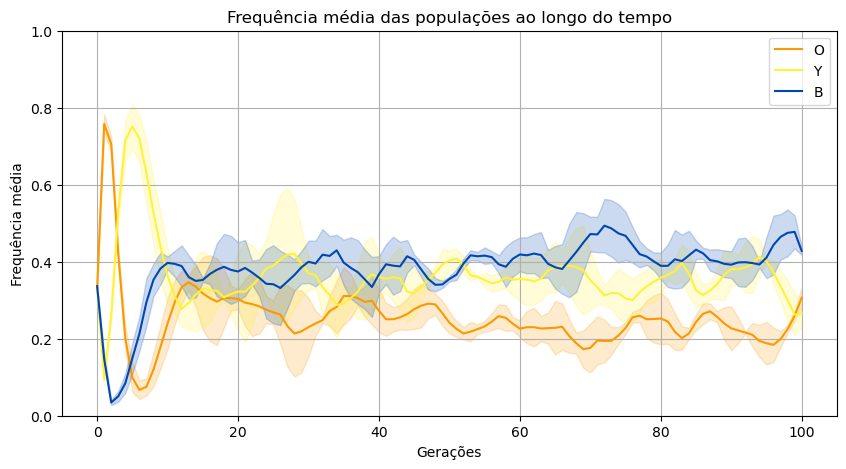

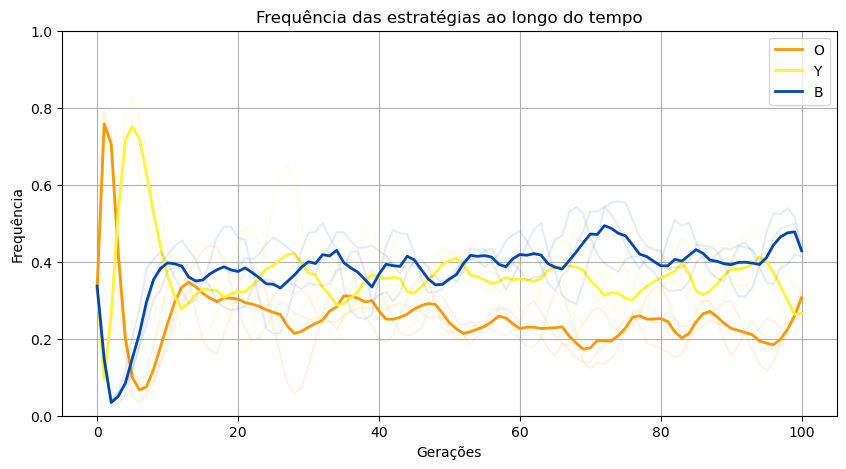

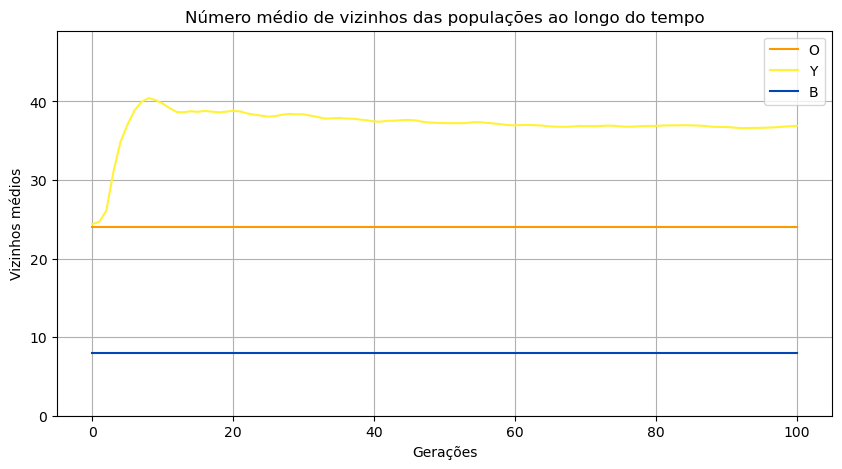

TESTS PASSED: Médias calculadas e gráficos gerados com sucesso.


In [ ]:
# python
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

# Parâmetros
cores = {"O": "#FD9800", "B": "#0047B3", "Y": "#FFF237"}

# Carregar dados salvos
freqs = []
n_vizinhos = []
for pop in range(n_pop):
    freq_path = os.path.join(output_dir, f"pop_{pop}_matriz_frequencias.npy")
    viz_path = os.path.join(output_dir, f"pop_{pop}_matriz_n_vizinhos_media.npy")
    freqs.append(np.load(freq_path))
    n_vizinhos.append(np.load(viz_path))
freqs = np.stack(freqs, axis=1)  # shape: (n_geracoes+1, n_pop, 3)
n_vizinhos = np.stack(n_vizinhos, axis=1)  # shape: (n_geracoes+1, n_pop, 3)

# Média das populações
freqs_mean = np.mean(freqs, axis=1)  # shape: (n_geracoes+1, 3)
freqs_std = np.std(freqs, axis=1)
n_vizinhos_mean = np.mean(n_vizinhos, axis=1)  # shape: (n_geracoes+1, 3)
n_vizinhos_std = np.std(n_vizinhos, axis=1)

# Testes de valores plausíveis
if not np.allclose(np.sum(freqs_mean, axis=1), 1):
    raise ValueError("Frequências médias não somam 1 em alguma geração.")
if not np.all((n_vizinhos_mean >= 0) & (n_vizinhos_mean <= 48)):
    raise ValueError("Número médio de vizinhos fora do intervalo [0,48].")
if not np.all((freqs_mean >= 0) & (freqs_mean <= 1)):
    raise ValueError("Frequências médias fora do intervalo [0,1].")

# DataFrames tidy para plot
linhas_freq = []
linhas_viz = []
for t in range(freqs_mean.shape[0]):
    for idx, strategy in enumerate(estrategias):
        linhas_freq.append({"t": t, "estrategia": strategy, "frequencia": freqs_mean[t, idx]})
        linhas_viz.append({"t": t, "estrategia": strategy, "n_vizinhos": n_vizinhos_mean[t, idx]})
df_freq = pd.DataFrame(linhas_freq)
df_viz = pd.DataFrame(linhas_viz)

# Gráfico de frequência média
plt.figure(figsize=(10, 5))
for idx, strategy in enumerate(estrategias):
    dados = df_freq[df_freq["estrategia"] == strategy]
    # Média
    plt.plot(dados["t"], dados["frequencia"], label=strategy, color=cores[strategy])
    # Desvio padrão (faixa)
    plt.fill_between(
        dados["t"],
        freqs_mean[:, idx] - freqs_std[:, idx],
        freqs_mean[:, idx] + freqs_std[:, idx],
        color=cores[strategy], alpha=0.2
    )
plt.title("Frequência média das populações ao longo do tempo")
plt.xlabel("Gerações")
plt.ylabel("Frequência média")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.savefig(output_dir + "frequencia_media.png")
plt.show()

# Gráfico de frequência média + linhas individuais
plt.figure(figsize=(10, 5))
for idx, strategy in enumerate(estrategias):
    # Todas as simulações (linhas claras)
    for pop in range(n_pop):
        plt.plot(freqs[:, pop, idx], color=cores[strategy], alpha=0.1)
    # Média (linha escura)
    plt.plot(freqs_mean[:, idx], color=cores[strategy], label=strategy, linewidth=2)
plt.title("Frequência das estratégias ao longo do tempo")
plt.xlabel("Gerações")
plt.ylabel("Frequência")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.savefig(output_dir + "frequencia_individual_e_media.png")
plt.show()

# Gráfico de vizinhos médio
plt.figure(figsize=(10, 5))
for strategy in estrategias:
    dados = df_viz[df_viz["estrategia"] == strategy]
    plt.plot(dados["t"], dados["n_vizinhos"], label=strategy, color=cores[strategy])
plt.title("Número médio de vizinhos das populações ao longo do tempo")
plt.xlabel("Gerações")
plt.ylabel("Vizinhos médios")
plt.ylim(0, 49)
plt.legend()
plt.grid(True)
plt.savefig(output_dir + "vizinhos_medios.png")
plt.show()

(3030000, 5)


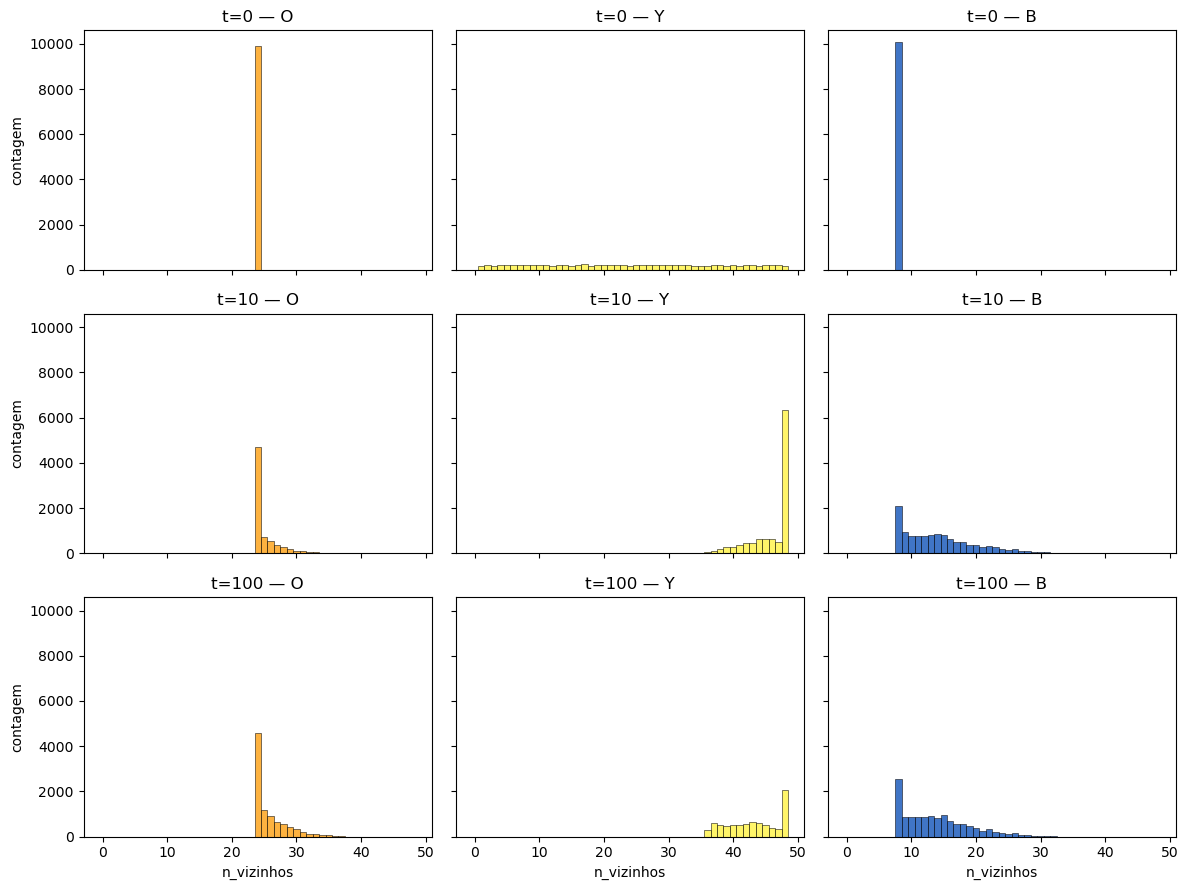

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import pickle
import os

# Parâmetros
times = [0, 10, 100]
strategies = ['O','Y','B']
cores = {"O": "#FD9800", "B": "#0047B3", "Y": "#FFF237"}

# Carregar dados salvos de todas as populações
rows = []
for pop in range(n_pop):
    with open(os.path.join(output_dir, f"pop_{pop}_n_vizinhos_individual.pkl"), "rb") as f:
        n_vizinhos_individual = pickle.load(f)
    with open(os.path.join(output_dir, f"pop_{pop}_historico_estrategias.pkl"), "rb") as f:
        historico_estrategias = pickle.load(f)
    for t in range(len(n_vizinhos_individual)):
        nv_gen = n_vizinhos_individual[t]
        est_gen = historico_estrategias[t]
        for i, (nv, est) in enumerate(zip(nv_gen, est_gen)):
            rows.append({"pop": pop, "t": t, "agent": i, "estrategia": est, "n_vizinhos": nv})
df_agents = pd.DataFrame(rows)

fig, axes = plt.subplots(nrows=len(times), ncols=len(strategies),
                         figsize=(4*len(strategies), 3*len(times)),
                         sharex=True, sharey=True)

bins = np.arange(0, 50) - 0.5  # rótulos inteiros 0..48

for i, t in enumerate(times):
    for j, e in enumerate(strategies):
        ax = axes[i, j] if len(times) > 1 else axes[j]
        # Junta todos os pops para cada tempo e estratégia
        vals = df_agents[(df_agents["t"] == t) & (df_agents["estrategia"] == e)]["n_vizinhos"]
        if vals.empty:
            ax.text(0.5, 0.5, "sem dados", ha='center', va='center')
        else:
            sns.histplot(vals, bins=bins, kde=False, color=cores[e], ax=ax)
        ax.set_title(f"t={t} — {e}")
        if j == 0:
            ax.set_ylabel("contagem")
        else:
            ax.set_ylabel("")
        if i == len(times)-1:
            ax.set_xlabel("n_vizinhos")
        else:
            ax.set_xlabel("")

plt.tight_layout()
plt.show()

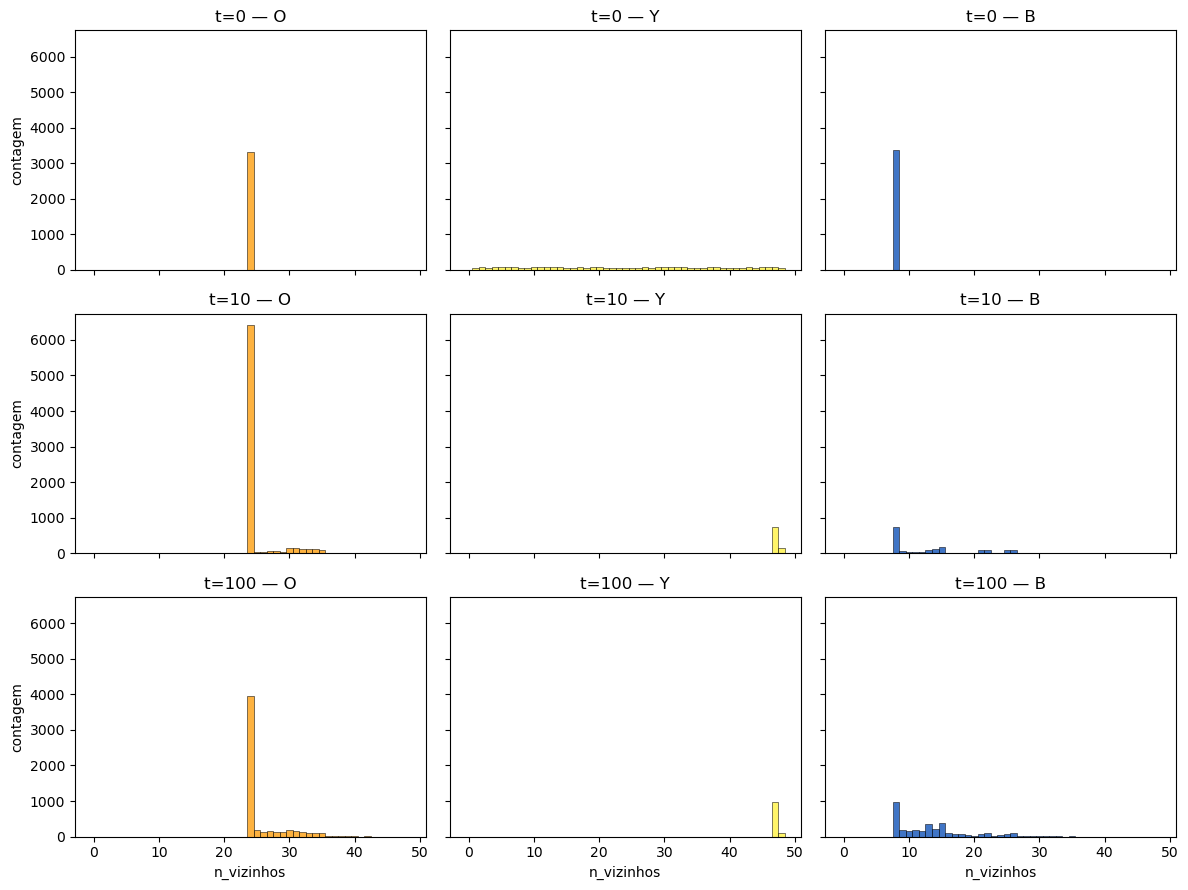

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# tempos e estratégias desejadas
times = [0, 10, 100]
strategies = ['O','Y','B']
cores = {"O": "#FD9800", "B": "#0047B3", "Y": "#FFF237"}

rows = []
for pop in range(len(n_vizinhos_individual)):
    for t in range(len(n_vizinhos_individual[pop])):
        nv_gen = n_vizinhos_individual[pop][t]
        est_gen = historico_estrategias[pop][t]
        for i, (nv, est) in enumerate(zip(nv_gen, est_gen)):
            rows.append({"pop": pop, "t": t, "agent": i, "estrategia": est, "n_vizinhos": nv})
df_agents = pd.DataFrame(rows)

fig, axes = plt.subplots(nrows=len(times), ncols=len(strategies),
                         figsize=(4*len(strategies), 3*len(times)),
                         sharex=True, sharey=True)

bins = np.arange(0, 50) - 0.5  # rótulos inteiros 0..48

for i, t in enumerate(times):
    for j, e in enumerate(strategies):
        ax = axes[i, j] if len(times) > 1 else axes[j]
        vals = df_agents[(df_agents["pop"] == 0) & (df_agents["t"] == t) & (df_agents["estrategia"] == e)]["n_vizinhos"]
        if vals.empty:
            ax.text(0.5, 0.5, "sem dados", ha='center', va='center')
        else:
            sns.histplot(vals, bins=bins, kde=False, color=cores[e], ax=ax)
        ax.set_title(f"t={t} — {e}")
        if j == 0:
            ax.set_ylabel("contagem")
        else:
            ax.set_ylabel("")
        if i == len(times)-1:
            ax.set_xlabel("n_vizinhos")
        else:
            ax.set_xlabel("")

plt.tight_layout()
plt.show()

In [55]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt

def simulacao_gif(n_geracoes, L, n_lagartos, estrategias, index_map, seed = 10):

    matrizes_posicao_hist = [] # lista para armazenar as matrizes de posição de cada geração
    matrizes_fitness_hist = []

    if seed is not None:
        np.random.seed(seed) # coloca uma semente diferente pra cada pop

    matriz_posicao = np.full((L, L), None) # cria uma matriz vazia com None
    matriz_fitness = np.full((L, L), 0.0) # cria uma matriz vazia com 0

    # criando a matriz inicial
    lista_lagartos = criar_lagartos(n_lagartos, L, estrategias)
    for lagarto in lista_lagartos:
      lagarto.adicionar_vizinhos_inicial() # adiciona o número de vizinhos iniciais de acordo com a estratégia
      matriz_posicao[lagarto.i, lagarto.j] = str(lagarto.estrategia) # cria a matriz de posições de acordo com os lagartos

    matrizes_posicao_hist.append(matriz_posicao.copy()) # junta as matrizes em uma lista
    matrizes_fitness_hist.append(matriz_fitness.copy())

    for t in range(1, n_geracoes + 1): # loop para cada geração dentro da população
        # atualiza a matriz de posição com as novas estratégias
        for lagarto in lista_lagartos:
          matriz_posicao[lagarto.i, lagarto.j] = str(lagarto.estrategia)
        
        # determinando os vizinhos
        for lagarto in lista_lagartos:
          lagarto.calcular_coord_vizinhos(L) # calcula as coordenadas dos vizinhos
          lagarto.obter_estrategia_vizinhos(matriz_posicao) # obtém as estratégias dos vizinhos
          # zera a vizinhança estendida para recalcular a cada lagarto
          lagarto.coord_vizinhanca_extendida = [] 
          lagarto.estrategia_vizinhanca_extendida = [] 

        ajustar_vizinhos_reciprocos(lista_lagartos) # ajusta as vizinhanças recíprocas

        for lagarto in lista_lagartos:
          lagarto.calcular_n_vizinhos() # calcula o número de vizinhos efetivo

        # calculando o fitness
        for lagarto in lista_lagartos:
          calcular_fitness(lagarto, index_map, matriz_posicao) # calcula o fitness do lagarto de acordo com seus vizinhos e a matriz de fitness

        for lagarto in lista_lagartos:
          matriz_fitness[lagarto.i, lagarto.j] = float(lagarto.fitness) # coloca os fitness nas posições

        lista_lagartos = atualizar_lagartos(lista_lagartos) # atualiza as estratégias dos lagartos de acordo com o maior fitness dos vizinhos

        for lagarto in lista_lagartos:
            lagarto.t += 1

        matrizes_posicao_hist.append(matriz_posicao.copy()) # Append updated matrix position
        matrizes_fitness_hist.append(matriz_fitness.copy())

    return matrizes_posicao_hist, matrizes_fitness_hist # Return both frequencies and matrix history

matrizes_posicao_hist, matrizes_fitness_hist = simulacao_gif(n_geracoes, L, n_lagartos, estrategias, index_map, seed=10)

In [56]:
# gerando o GIF das posições

import matplotlib.colors as mcolors
import matplotlib.animation as animation

cores_grid = {"O": "#FD9800", "B": "#0047B3", "Y": "#FFF237"}

def matriz_para_rgb(matriz):
    return np.array(
        [[mcolors.to_rgb(cores_grid.get(cell, "#FFFFFF")) for cell in row] for row in matriz],
        dtype=float
    )

# Crie a figura
fig, ax = plt.subplots(figsize=(6, 6))

def update(frame):
    ax.clear()
    ax.imshow(matriz_para_rgb(matrizes_posicao_hist[frame]))
    ax.set_title(f"Geração {frame}")
    ax.axis('off')

ani = animation.FuncAnimation(
    fig, update, frames=len(matrizes_posicao_hist), interval=100, repeat=False
)
# 👉 Salvar em arquivo GIF
ani.save("C:\\Unicamp\\mestrado\\simulacoes\\RPS-python\\animacao.gif", writer="pillow", fps=10)

plt.close()

# gerando o GIF dos fitness

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(matrizes_fitness_hist[0], cmap='viridis', vmin=0, vmax=np.max(matrizes_fitness_hist))
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Fitness')

def update_fitness(frame):
    im.set_data(matrizes_fitness_hist[frame])
    ax.set_title(f"Fitness - Geração {frame}")
    ax.axis('off')
    return [im]

ani = animation.FuncAnimation(
    fig, update_fitness, frames=len(matrizes_fitness_hist), interval=100, blit=False, repeat=False
)

ani.save(os.path.join("C:\\Unicamp\\mestrado\\simulacoes\\RPS-python\\animacao_fitness.gif"), writer='pillow', fps=10)
plt.close()